<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Project/blob/main/MSCS_634_Project_Deliverable4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 4: Consolidated Notebook (Deliverables 1, 2 & 3),Final Insights, Recommendations, and Presentation

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)

---

This notebook consolidates all work from Deliverables 1, 2, and 3 into a single runnable file.  
Just place `framingham.csv` in the same directory and run all cells top to bottom.

**Contents:**
1. Library Imports & Setup
2. Load Dataset
3. Data Preprocessing (Missing Values, Duplicates, Outliers)
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Regression Modeling (predict `sysBP`)
7. Classification Modeling (predict `TenYearCHD`)
8. Clustering — K-Means
9. Association Rule Mining — Apriori
10. Results Summary


The **Framingham Heart Study** dataset was selected from Kaggle. It originates from one of the longest-running cardiovascular studies in the United States, conducted by the National Heart, Lung, and Blood Institute (NHLBI). The dataset contains clinical measurements, lifestyle habits, and medical history collected to study 10-year coronary heart disease (CHD) risk.

It was chosen because it satisfies all project requirements in a single file:
- **4,240 records** — well above the 500+ minimum
- **16 attributes** (15 input features + 1 binary target) — exceeds the 8–10 minimum
- **7 columns with real missing values** — supports genuine imputation technique comparison
- **Target variable:** `TenYearCHD` — binary (0/1), suitable for classification
- **Continuous features:** `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose` — suitable for regression
- **Binary features:** `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes` — suitable for Association Rule Mining
- **Rich numeric space:** `age`, `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose`, `heartRate` — suitable for clustering

| Technique | Coverage |
|---|---|
| Preprocessing, EDA | Missing value imputation, outlier Winsorization, 8 EDA visualizations |
| Feature engineering, Regression | Predict `sysBP` or `glucose`; engineer `pulse_pressure`, risk scores |
| Classification | Predict `TenYearCHD` using Decision Tree, Logistic Regression, Naive Bayes |
| Clustering  | K-Means on clinical features; Apriori on binarized flags |

**Dataset on Kaggle:** https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset

## 1. Library Imports & Setup

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn — preprocessing and modeling
from sklearn.impute import KNNImputer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      KFold, GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, silhouette_score, ConfusionMatrixDisplay
)

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules

# Save all visualizations to this folder
os.makedirs('Visualizations', exist_ok=True)
print("All libraries loaded successfully.")


All libraries loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 2. Load Dataset

In [3]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

Saving framingham.csv to framingham.csv


{'framingham.csv': b'male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD\r1,39,4,0,0,0,0,0,0,195,106,70,26.97,80,77,0\r0,46,2,0,0,0,0,0,0,250,121,81,28.73,95,76,0\r1,48,1,1,20,0,0,0,0,245,127.5,80,25.34,75,70,0\r0,61,3,1,30,0,0,1,0,225,150,95,28.58,65,103,1\r0,46,3,1,23,0,0,0,0,285,130,84,23.1,85,85,0\r0,43,2,0,0,0,0,1,0,228,180,110,30.3,77,99,0\r0,63,1,0,0,0,0,0,0,205,138,71,33.11,60,85,1\r0,45,2,1,20,0,0,0,0,313,100,71,21.68,79,78,0\r1,52,1,0,0,0,0,1,0,260,141.5,89,26.36,76,79,0\r1,43,1,1,30,0,0,1,0,225,162,107,23.61,93,88,0\r0,50,1,0,0,0,0,0,0,254,133,76,22.91,75,76,0\r0,43,2,0,0,0,0,0,0,247,131,88,27.64,72,61,0\r1,46,1,1,15,0,0,1,0,294,142,94,26.31,98,64,0\r0,41,3,0,0,1,0,1,0,332,124,88,31.31,65,84,0\r0,39,2,1,9,0,0,0,0,226,114,64,22.35,85,NA,0\r0,38,2,1,20,0,0,1,0,221,140,90,21.35,95,70,1\r1,48,3,1,10,0,0,1,0,232,138,90,22.37,64,72,0\r0,46,2,1,20,0,0,0,0,291,112,78,23.38,80,89,1\r0,38,2,1,5,0

In [4]:
# Load the Framingham Heart Study dataset
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
print("\nFirst 5 rows:")
df.head()


Dataset loaded: 4,240 rows x 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
# Basic statistics with coefficient of variation and missing value summary
print("Statistical Summary")
print("=" * 50)
desc = df.describe().T
desc["cv"] = (desc["std"] / desc["mean"]).round(3)
desc['missing'] = df.isnull().sum()
desc['missing_%'] = (df.isnull().sum() / len(df) * 100).round(2)
desc.round(3)

Statistical Summary


,count,mean,std,min,25%,50%,75%,max,cv,missing,missing_%
male,4240.0,0.429,0.495,0.00,0.00,0.0,1.00,1.0,1.153,0,0.00
age,4240.0,49.580,8.573,32.00,42.00,49.0,56.00,70.0,0.173,0,0.00
education,4135.0,1.979,1.020,1.00,1.00,2.0,3.00,4.0,0.515,105,2.48
currentSmoker,4240.0,0.494,0.500,0.00,0.00,0.0,1.00,1.0,1.012,0,0.00
cigsPerDay,4211.0,9.006,11.922,0.00,0.00,0.0,20.00,70.0,1.324,29,0.68
BPMeds,4187.0,0.030,0.170,0.00,0.00,0.0,0.00,1.0,5.725,53,1.25
prevalentStroke,4240.0,0.006,0.077,0.00,0.00,0.0,0.00,1.0,12.986,0,0.00
prevalentHyp,4240.0,0.311,0.463,0.00,0.00,0.0,1.00,1.0,1.490,0,0.00
diabetes,4240.0,0.026,0.158,0.00,0.00,0.0,0.00,1.0,6.157,0,0.00
totChol,4190.0,236.700,44.591,107.00,206.00,234.0,263.00,696.0,0.188,50,1.18


## 3. Data Preprocessing

### 3.1 Missing Value Analysis


In [6]:
# Check which columns have missing values and how many
print("Missing Value Analysis")
print("=" * 50)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({"missing_count": missing_values, "missing_%": missing_percent})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_%", ascending=False)
print(missing_df)
print(f"\nTotal missing values across all columns: {df.isnull().sum().sum()}")


Missing Value Analysis
            missing_count  missing_%
glucose               388   9.150943
education             105   2.476415
BPMeds                 53   1.250000
totChol                50   1.179245
cigsPerDay             29   0.683962
BMI                    19   0.448113
heartRate               1   0.023585

Total missing values across all columns: 645


### 3.2 Imputation Strategy Comparison (glucose)

Three strategies were compared on `glucose` (the column with the highest missingness at 9.15%):
- **Mean imputation** — simple, but pulled upward by extreme diabetic values in right-skewed distributions
- **Median imputation** — robust to skew and outliers; preferred for clinical measurements
- **KNN imputation** — uses neighboring records for accuracy, but computationally heavier

The comparison chart showed mean=82.0, median=78.0, KNN avg=81.1. Since `glucose` is heavily right-skewed (skew=2.52), **median imputation** was applied to all numeric columns with missing values.
For `education` (ordinal) and `BPMeds` (binary), **mode imputation** was applied since mean/median have no valid interpretation for categorical columns.


Imputation comparison for 'glucose' (skew = 6.21):
  Mean imputed value   : 81.96
  Median imputed value : 78.00
  KNN avg imputed value: 81.11

Decision: glucose is right-skewed => median imputation preferred.


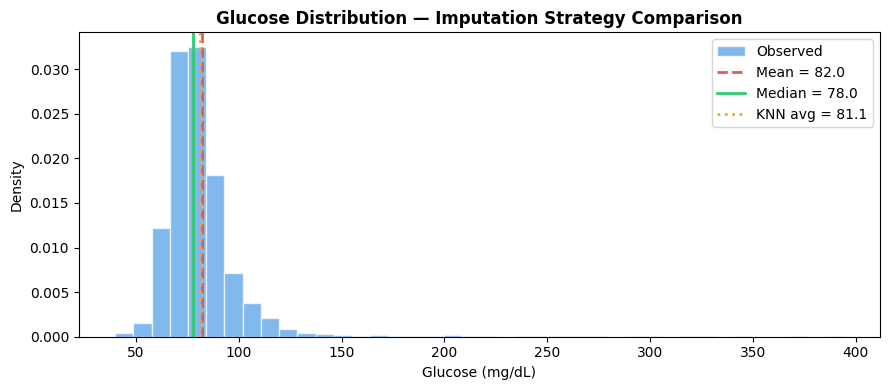

In [7]:
# Compare three imputation strategies for glucose
non_null_glucose = df['glucose'].dropna()

mean_val   = df['glucose'].mean()
median_val = df['glucose'].median()

# KNN imputation on numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
knn_imp = KNNImputer(n_neighbors=5)
df_knn_temp = pd.DataFrame(knn_imp.fit_transform(df[numeric_cols]), columns=numeric_cols)
knn_val = df_knn_temp.loc[df['glucose'].isnull(), 'glucose'].mean()

print(f"Imputation comparison for 'glucose' (skew = {non_null_glucose.skew():.2f}):")
print(f"  Mean imputed value   : {mean_val:.2f}")
print(f"  Median imputed value : {median_val:.2f}")
print(f"  KNN avg imputed value: {knn_val:.2f}")
print("\nDecision: glucose is right-skewed => median imputation preferred.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(non_null_glucose, bins=40, color='#4C9BE8', edgecolor='white', alpha=0.7, density=True, label='Observed')
ax.axvline(mean_val,   color='#E05C5C', linestyle='--', lw=2, label=f'Mean = {mean_val:.1f}')
ax.axvline(median_val, color='#2ECC71', linestyle='-',  lw=2, label=f'Median = {median_val:.1f}')
ax.axvline(knn_val,    color='#F5A623', linestyle=':',  lw=2, label=f'KNN avg = {knn_val:.1f}')
ax.set_title('Glucose Distribution — Imputation Strategy Comparison', fontweight='bold')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('Visualizations/1_imputation_comparison.png', bbox_inches='tight')
plt.show()


### 3.3 Apply Imputation and Clean Dataset

In [8]:
# Copy raw dataframe — all cleaning applied to df_clean_data
df_clean_data = df.copy()

# Median imputation for numeric columns with missing values
numeric_missing = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
for col in numeric_missing:
    median_val = df[col].median()
    df_clean_data[col].fillna(median_val, inplace=True)
    print(f"  Imputed '{col}' with median = {median_val:.2f}")

# Mode imputation for ordinal and binary columns
non_numeric_missing = ["education", "BPMeds"]
for col in non_numeric_missing:
    mode_val = df[col].mode()[0]
    df_clean_data[col].fillna(mode_val, inplace=True)
    print(f"  Imputed '{col}' with mode = {mode_val}")

print(f"\nRemaining missing values: {df_clean_data.isnull().sum().sum()}")


  Imputed 'glucose' with median = 78.00
  Imputed 'BPMeds' with median = 0.00
  Imputed 'totChol' with median = 234.00
  Imputed 'BMI' with median = 25.40
  Imputed 'heartRate' with median = 75.00
  Imputed 'cigsPerDay' with median = 0.00
  Imputed 'education' with mode = 1.0
  Imputed 'BPMeds' with mode = 0.0

Remaining missing values: 0


In [9]:
# Duplicate detection
duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Duplicate rows found: {duplicate_cnt}")
if duplicate_cnt > 0:
    df_clean_data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df_clean_data.shape}")
else:
    print("No duplicates found — no action needed.")
print(f"Dataset shape: {df_clean_data.shape}")


Duplicate rows found: 0
No duplicates found — no action needed.
Dataset shape: (4240, 16)


### 3.4 Outlier Detection and Winsorization
**Detection:** IQR method — values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged.

**Treatment — Winsorization (1st–99th percentile capping):**  
Extreme values are clipped to the 1st and 99th percentile bounds using `pandas.Series.clip()`. This approach is preferred over dropping records because:
- All 4,240 patient records are preserved — no data loss
- Extreme clinical values (e.g., very high blood pressure, severe hyperglycemia) may represent genuinely high-risk patients
- IQR fencing alone is overly aggressive for skewed clinical features
- Winsorization is the standard technique in academic preprocessing pipelines (Tukey, 1977)

> Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.


In [10]:
# Step 1: Detect outliers with IQR method
continuous_cols   = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]
discrete_num_cols = ["age", "cigsPerDay", "heartRate"]
all_numeric_cols  = continuous_cols + discrete_num_cols

print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)
outlier_report = {}
for col in all_numeric_cols:
    Q1 = df_clean_data[col].quantile(0.25)
    Q3 = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    outlier_report[col] = n_out
    print(f"  {col:<15} | fence: [{lower:6.1f}, {upper:6.1f}] | Outliers: {n_out:>4} ({n_out/len(df_clean_data)*100:.1f}%)")
print(f"\nTotal outliers detected: {sum(outlier_report.values()):,}")

# Step 2: Winsorization (1st-99th percentile capping)
print("\nSTEP 2 — WINSORIZATION (1st–99th percentile capping)")
print("=" * 65)
for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_capped = ((df_clean_data[col] < p01) | (df_clean_data[col] > p99)).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    print(f"  {col:<15} | P1={p01:>7.2f}  P99={p99:>7.2f} | Capped: {n_capped}")

print(f"\nPreprocessing complete. Working dataframe: df_clean_data, shape: {df_clean_data.shape}")


STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | fence: [  52.5,  104.5] | Outliers:  262 (6.2%)
  age             | fence: [  21.0,   77.0] | Outliers:    0 (0.0%)
  cigsPerDay      | fence: [ -30.0,   50.0] | Outliers:   12 (0.3%)
  heartRate       | fence: [  45.5,  105.5] | Outliers:   76 (1.8%)

Total outliers detected: 707

STEP 2 — WINSORIZATION (1st–99th percentile capping)
  totChol         | P1= 153.39  P99= 353.61 | Capped: 86
  sysBP           | P1=  97.00  P99= 200.00 | Capped: 81
  diaBP           | P1=  60.00  P99= 118.00 | Capped: 80
  BMI             | P1=  18.17  P99=  38.95 | Capped: 86
  glucose         | P1=  56.00  P99= 170.00 | Capped: 83
  age             | P1=  35.00  P99=  67.00 | C

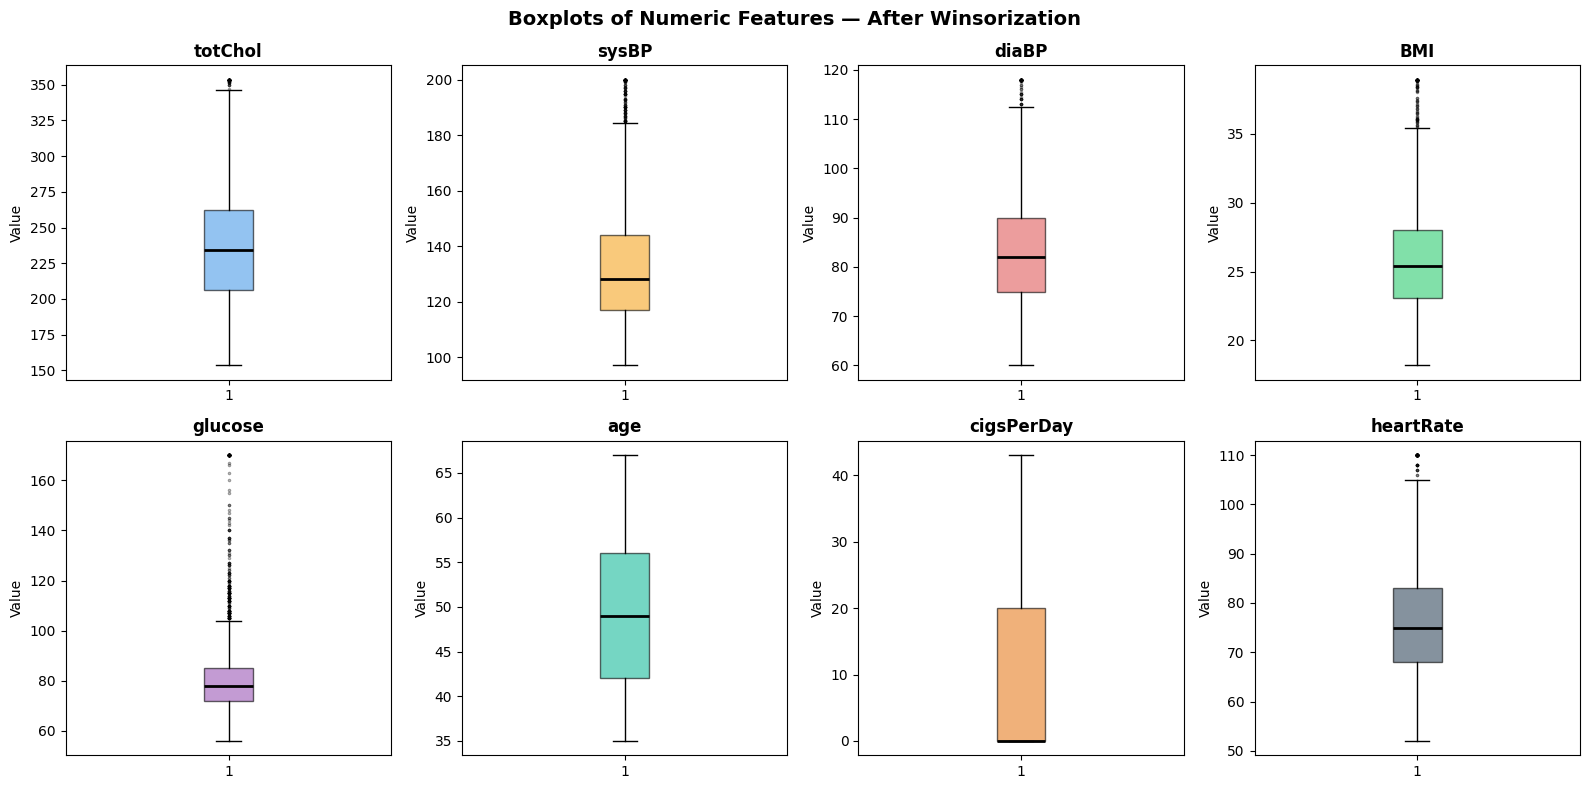

Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.
Min/max annotations in each subplot confirm the capped value ranges.


In [11]:
# ------------------------------------------------------------------------------
# Boxplots of All Numeric Features (Post-Winsorization)
# Purpose: Visually confirm that Winsorization was applied correctly.
# After capping:
#   - Whiskers should terminate at or near the 1st/99th percentile bounds
#   - Any remaining fliers fall within clinically accepted ranges
#   - Median lines and IQR boxes remain unchanged (capping only affects extremes)
# Layout: 2×4 grid — continuous cols first, then discrete count cols
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Boxplots of Numeric Features — After Winsorization",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

colors = ["#4C9BE8", "#F5A623", "#E05C5C", "#2ECC71",
          "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"]

for ax, col, color in zip(axes, all_numeric_cols, colors):
    ax.boxplot(df_clean_data[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig("Visualizations/2_boxplots_post_winsorization.png", bbox_inches="tight")
plt.show()
print("Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.")
print("Min/max annotations in each subplot confirm the capped value ranges.")